# Registration Tutorial

This notebook demonstrates how to use the `ArunsRigidRegistrator` class for rigid image registration using anatomical landmarks. We'll show how to:

1. Use the `CSVPointExtractor` to load custom landmarks from the CSV
2. Demonstrate the `map_coordinates` method for transforming individual coordinates
3. Demonstrate the `map_segmentation` method for transforming entire segmentation masks

### Import Required Libraries

In [1]:
import glob
import os
import tempfile
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from monai.apps import download_and_extract

from linguine.constants import FILE_ID, IMAGE, LABEL
from linguine.image_loaders.base_image_loader import BaseImageLoader
from linguine.registration.point_extractors.csv_extractor import CSVPointExtractor
from linguine.registration.registrators import ArunsRigidRegistrator
from linguine.utils.data import get_spacing_from_metatensor

### Download Sample Data

We'll use the Medical Segmentation Decathlon Task 9 (Spleen) dataset for the purposes of this tutorial.

In [ ]:
resource = "https://msd-for-monai.s3-us-west-2.amazonaws.com/Task09_Spleen.tar"
md5 = "410d4a301da4e5b2f6f86ec3ddba524e"
root_dir = tempfile.mkdtemp()  # Edit this if you already have this dataset saved somewhere to save time.
compressed_file = os.path.join(root_dir, "Task09_Spleen.tar")
data_dir = os.path.join(root_dir, "Task09_Spleen")
if not os.path.exists(data_dir):
    download_and_extract(resource, compressed_file, root_dir, md5)
print(f"Data downloaded to: {data_dir}")

Data downloaded to: /tmp/tmpyshwy4u0/Task09_Spleen


### Prepare Data Dictionaries

We'll use two scans from the dataset to demonstrate registration between them.

In [4]:
train_images = sorted(glob.glob(os.path.join(data_dir, "imagesTr", "*.nii.gz")))
train_labels = sorted(glob.glob(os.path.join(data_dir, "labelsTr", "*.nii.gz")))

# Select two scans for demonstration. The following two were selected due to similar spacings in z.
source_dict = {IMAGE: train_images[3], LABEL: train_labels[3], FILE_ID: os.path.basename(train_images[3]).split(".")[0]}
target_dict = {IMAGE: train_images[0], LABEL: train_labels[0], FILE_ID: os.path.basename(train_images[0]).split(".")[0]}
print(f"Source scan: {source_dict[FILE_ID]} at {source_dict[IMAGE]}")
print(f"Target scan: {target_dict[FILE_ID]} at {target_dict[IMAGE]}")

Source scan: spleen_14 at /tmp/tmpyshwy4u0/Task09_Spleen/imagesTr/spleen_14.nii.gz
Target scan: spleen_10 at /tmp/tmpyshwy4u0/Task09_Spleen/imagesTr/spleen_10.nii.gz


### Load Images and Examine Their Properties

In [6]:
# Load the images using LinGuinE's base image loader
image_loader = BaseImageLoader()
source_img, source_label = image_loader(source_dict)
target_img, target_label = image_loader(target_dict)

# Extract the actual arrays (remove batch and channel dimensions)
source_img, source_label = source_img[0][0], source_label[0][0]
target_img, target_label = target_img[0][0], target_label[0][0]

# Compute the spacing of each image
source_spacing = get_spacing_from_metatensor(img=source_img)
target_spacing = get_spacing_from_metatensor(img=target_img)

print(f"Source image shape: {tuple(source_img.shape)}, spacing: {source_spacing}")
print(f"Target image shape: {tuple(target_img.shape)}, spacing: {target_spacing}")

Source image shape: (512, 512, 54), spacing: (0.8515620231628418, 0.8515620231628418, 5.0)
Target image shape: (512, 512, 55), spacing: (0.9765620231628418, 0.9765620231628418, 5.0)


### Extract Spleen Edge Landmarks from Ground Truth Labels

We'll very naively compute the edges and centers of the spleen from the ground truth segmentation masks. These landmarks will be used for registration in this tutorial. These are not optimal landmarks and are simply for demonstration purposes.

However this cell shows that you can create landmarks in any way that you see fit for your data when running LinGuinE or registration, you would simply then have to put it into the format of a dataframe as below.

In [19]:
def extract_spleen_edge_landmarks(label_array: np.ndarray, file_id: str) -> list[dict[str, Any]]:
    """Extract spleen edge landmarks from a segmentation label array.
    Args:
        label_array: 3D numpy array containing the segmentation labels
        file_id: identifier for this scan
    Returns:
        List of landmark dictionaries with coordinates
    """
    landmarks = []
    # Find spleen voxels
    spleen_mask = label_array == 1
    # Get coordinates of all spleen voxels
    spleen_coords = np.where(spleen_mask)
    x_coords, y_coords, z_coords = spleen_coords
    # Extract edge landmarks
    landmark_definitions = [
        ("spleen_top", np.argmin(z_coords)),
        ("spleen_bottom", np.argmax(z_coords)),
        ("spleen_left", np.argmax(y_coords)),
        ("spleen_right", np.argmin(y_coords)),
        ("spleen_front", np.argmin(x_coords)),
        ("spleen_back", np.argmax(x_coords)),
    ]
    for landmark_name, idx in landmark_definitions:
        landmarks.append(
            {
                FILE_ID: file_id,
                "name": landmark_name,
                "x": int(x_coords[idx]),
                "y": int(y_coords[idx]),
                "z": int(z_coords[idx]),
            }
        )
    # Also add spleen center as an additional landmark
    center_x = int(np.mean(x_coords))
    center_y = int(np.mean(y_coords))
    center_z = int(np.mean(z_coords))

    landmarks.append({FILE_ID: file_id, "name": "spleen_center", "x": center_x, "y": center_y, "z": center_z})
    return landmarks


# Extract landmarks for both scans
source_landmarks = extract_spleen_edge_landmarks(source_label.cpu().numpy(), "spleen_14")
target_landmarks = extract_spleen_edge_landmarks(target_label.cpu().numpy(), "spleen_10")

# Combine into a single DataFrame
landmark_df = pd.DataFrame(source_landmarks + target_landmarks)
print("\nCreated landmark dataset:")
print(landmark_df)


Created landmark dataset:
      file_id           name    x    y   z
0   spleen_14     spleen_top   87  242  23
1   spleen_14  spleen_bottom  123  245  43
2   spleen_14    spleen_left   97  315  28
3   spleen_14   spleen_right  129  160  30
4   spleen_14   spleen_front   81  244  25
5   spleen_14    spleen_back  215  231  36
6   spleen_14  spleen_center  131  231  34
7   spleen_10     spleen_top   91  235  23
8   spleen_10  spleen_bottom  138  234  39
9   spleen_10    spleen_left  107  297  29
10  spleen_10   spleen_right  134  185  31
11  spleen_10   spleen_front   87  251  26
12  spleen_10    spleen_back  193  216  35
13  spleen_10  spleen_center  129  228  31


### Save Landmarks to CSV and Load with CSVPointExtractor
This cell demonstrates how to use the inbuilt point extractor object that is designed to interfacte with the inbuilt registration algorithms and the rest of LinGuinE in tandem with a customised landmarks that was not generated with the assets in this package.

In [8]:
# Save landmarks to a temporary CSV file
landmark_csv_path = os.path.join(root_dir, "spleen_edge_landmarks.csv")
landmark_df.to_csv(landmark_csv_path, index=False)
print(f"Landmarks saved to: {landmark_csv_path}")

# Create a CSVPointExtractor to load landmarks from the CSV
csv_extractor = CSVPointExtractor(
    landmark_csv_path=landmark_csv_path,
    img_identifier_colname=FILE_ID,
    landmark_id_colname="name",
    x_colname="x",
    y_colname="y",
    z_colname="z",
)

print(f"Available landmark IDs: {csv_extractor.valid_ids}")

# Extract landmarks for both scans
source_landmarks_dict = csv_extractor.extract_points(source_dict)
target_landmarks_dict = csv_extractor.extract_points(target_dict)

print(f"\nSource landmarks extracted: {len(source_landmarks_dict)}")
print(f"Target landmarks extracted: {len(target_landmarks_dict)}")

# Display all landmarks
print("\nSource landmarks:")
for name, landmark in source_landmarks_dict.items():
    print(f"  {name}: ({landmark.x}, {landmark.y}, {landmark.z})")
print("\nTarget landmarks:")
for name, landmark in target_landmarks_dict.items():
    print(f"  {name}: ({landmark.x}, {landmark.y}, {landmark.z})")

Landmarks saved to: /tmp/tmpyshwy4u0/spleen_edge_landmarks.csv
Available landmark IDs: {'spleen_back', 'spleen_bottom', 'spleen_right', 'spleen_top', 'spleen_front', 'spleen_left', 'spleen_center'}

Source landmarks extracted: 7
Target landmarks extracted: 7

Source landmarks:
  spleen_top: (87, 242, 23)
  spleen_bottom: (123, 245, 43)
  spleen_left: (97, 315, 28)
  spleen_right: (129, 160, 30)
  spleen_front: (81, 244, 25)
  spleen_back: (215, 231, 36)
  spleen_center: (131, 231, 34)

Target landmarks:
  spleen_top: (91, 235, 23)
  spleen_bottom: (138, 234, 39)
  spleen_left: (107, 297, 29)
  spleen_right: (134, 185, 31)
  spleen_front: (87, 251, 26)
  spleen_back: (193, 216, 35)
  spleen_center: (129, 228, 31)


### Initialize the ArunsRigidRegistrator

Note that any registration algorithm in the registrators module can be used in the exact same way!

In [20]:
# Initialize the registrator
# We can specify which landmarks to use for registration
# We will use all of them except for the center landmark, which will instead be used for validation.
registrator = ArunsRigidRegistrator(
    valid_landmarks=["spleen_top", "spleen_bottom", "spleen_left", "spleen_right", "spleen_front", "spleen_back"],
)
print(f"Registrator initialized with landmarks: {registrator.valid_landmarks}")

Registrator initialized with landmarks: ['spleen_top', 'spleen_bottom', 'spleen_left', 'spleen_right', 'spleen_front', 'spleen_back']


### Demonstrate the map_coordinates Method

The `map_coordinates` method transforms individual coordinate points from the source image space to the target image space using the rigid transformation calculated from landmarks. This is the logic that propagates guidance clicks between scans in LinGuinE.

In [21]:
test_landmark_coordinate = source_landmarks_dict["spleen_center"]
test_coors = [(test_landmark_coordinate.x, test_landmark_coordinate.y, test_landmark_coordinate.z)]

print(f"Original coordinate in source image: {test_coors[0]}")

# Transform coordinates to target image space
transformed_coordinates = registrator.map_coordinates(
    source_spacing=source_spacing,
    target_spacing=target_spacing,
    source_landmarks=source_landmarks_dict,
    target_landmarks=target_landmarks_dict,
    coors=test_coors,
    round=True,
)

print(f"Transformed coordinate in target image: {tuple([int(x) for x in transformed_coordinates[0]])}")
print(
    f"Actual center point in target image: ({target_landmarks_dict['spleen_center'].x}, {target_landmarks_dict['spleen_center'].y}, {target_landmarks_dict['spleen_center'].z})"
)

Original coordinate in source image: (131, 231, 34)
Transformed coordinate in target image: (134, 228, 33)
Actual center point in target image: (129, 228, 31)


### Demonstrate the map_segmentation Method

The `map_segmentation` method transforms an entire segmentation mask from the source image space to the target image space. This can be useful for propagating organ segmentations or lesion masks between timepoints.

In [22]:
# Use the source spleen segmentation as our test segmentation
source_segmentation = source_label.cpu().numpy()
print(f"Source segmentation shape: {source_segmentation.shape}")
print(f"Source segmentation voxel count: {np.sum(source_segmentation > 0)}")

# Transform the segmentation to target image space
transformed_segmentation = registrator.map_segmentation(
    source_spacing=source_spacing,
    target_spacing=target_spacing,
    target_img_shape=target_img.shape,
    segmentation=source_segmentation,
    source_landmarks=source_landmarks_dict,
    target_landmarks=target_landmarks_dict,
)

print(f"\nTransformed segmentation shape: {transformed_segmentation.shape}")
print(f"Transformed segmentation voxel count: {np.sum(transformed_segmentation > 0)}")

Source segmentation shape: (512, 512, 54)
Source segmentation voxel count: 124163

Transformed segmentation shape: (512, 512, 55)
Transformed segmentation voxel count: 94524


### Visualize the Registration Results

Let's visualize the original and transformed segmentations to see how well the registration worked. The results will not be fantastic, since we are using a rigid algorithm based on 7 naively computed landmarks to register a deformable object between two different patients.

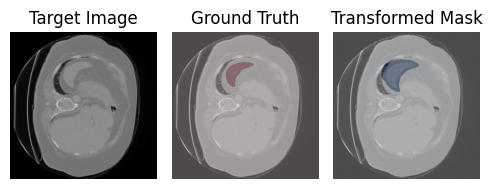

In [25]:
%matplotlib inline

# Choose a slice to visualize (one near the computed spleen center for example)
slice_idx = 34
fig, axes = plt.subplots(1, 3, figsize=(5, 2))

# Top row: Target image, target ground truth segmentation, transformed segmentation
axes[0].imshow(target_img[:, :, slice_idx], cmap="gray")
axes[0].set_title("Target Image")
axes[0].axis("off")

axes[1].imshow(target_label[:, :, slice_idx], cmap="Reds", alpha=0.9)
axes[1].imshow(target_img[:, :, slice_idx], cmap="gray", alpha=0.7)
axes[1].set_title("Ground Truth")
axes[1].axis("off")

axes[2].imshow(transformed_segmentation[:, :, slice_idx], cmap="Blues", alpha=0.9)
axes[2].imshow(target_img[:, :, slice_idx], cmap="gray", alpha=0.7)
axes[2].set_title("Transformed Mask")
axes[2].axis("off")

plt.tight_layout()
plt.show()

### Compute Registration Accuracy

Let's evaluate how well the registration worked by computing the distance between corresponding landmarks.

In [13]:
# Compute the registration error using the built-in method
registration_error = registrator.compute_dist(
    source_spacing=source_spacing,
    target_spacing=target_spacing,
    source_landmarks=source_landmarks_dict,
    target_landmarks=target_landmarks_dict,
    metric="euclidean",
)

print(f"Average landmark registration error: {registration_error:.2f} mm")

Average landmark registration error: 11.01 mm
